# Step 1

## Preparation

In [2]:
import pandas as pd
import numpy as np
import scipy.integrate as spi
import scipy.optimize as spo
import matplotlib.pyplot as plt
from scipy.stats import norm
import yfinance as yf

# Step 1: Data Preparation and Exploration

1. Download daily adjusted close prices using Yahoo finance

In [8]:
tickers = ['TLT', 'GLD', 'SPY', '^VIX']
data = yf.download(tickers, start='2000-01-01', end='2026-08-08', progress=False, auto_adjust=False)

# Extract Adjusted Close prices for ETFs and Close price for VIX
adj_close = data['Adj Close'].drop(columns=['^VIX'], errors='ignore')
vix_close = data['Close']['^VIX']

# Combine into a single DataFrame and find common dates
df = pd.concat([adj_close, vix_close], axis=1).dropna()
df.rename(columns={'^VIX': 'VIX'}, inplace=True)

print("Data downloaded and aligned. First 5 rows:")
display(df.head())

Data downloaded and aligned. First 5 rows:


,GLD,SPY,TLT,VIX
Date,,,,
2004-11-18,44.380001,79.745277,43.650948,12.98
2004-11-19,44.779999,78.858757,43.302635,13.50
2004-11-22,44.950001,79.234802,43.528271,12.97
2004-11-23,44.750000,79.355736,43.582291,12.67
2004-11-24,45.049999,79.543777,43.582291,12.72


2. Compute the daily log-returns for the ETFs and the daily change for VIX.

In [9]:
# Compute daily log-returns for ETFs
etf_returns = np.log(df[['TLT', 'GLD', 'SPY']] / df[['TLT', 'GLD', 'SPY']].shift(1)).dropna()
etf_returns.columns = [col + '_log_return' for col in etf_returns.columns]

# Compute daily change for VIX
vix_change = df['VIX'].diff().dropna()
vix_change.name = 'VIX_change'

# Combine all returns/changes
combined_data = pd.concat([etf_returns, vix_change], axis=1).dropna()

print("Computed returns and VIX change. First 5 rows:")
display(combined_data.head())

Computed returns and VIX change. First 5 rows:


,TLT_log_return,GLD_log_return,SPY_log_return,VIX_change
Date,,,,
2004-11-19,-0.008011,0.008973,-0.011179,0.520000
2004-11-22,0.005197,0.003789,0.004757,-0.530000
2004-11-23,0.001240,-0.004459,0.001525,-0.300000
2004-11-24,0.000000,0.006682,0.002367,0.050000
2004-11-26,-0.006551,0.005313,-0.000760,0.059999


3. Align the data series on common dates, remove any mising values and plot

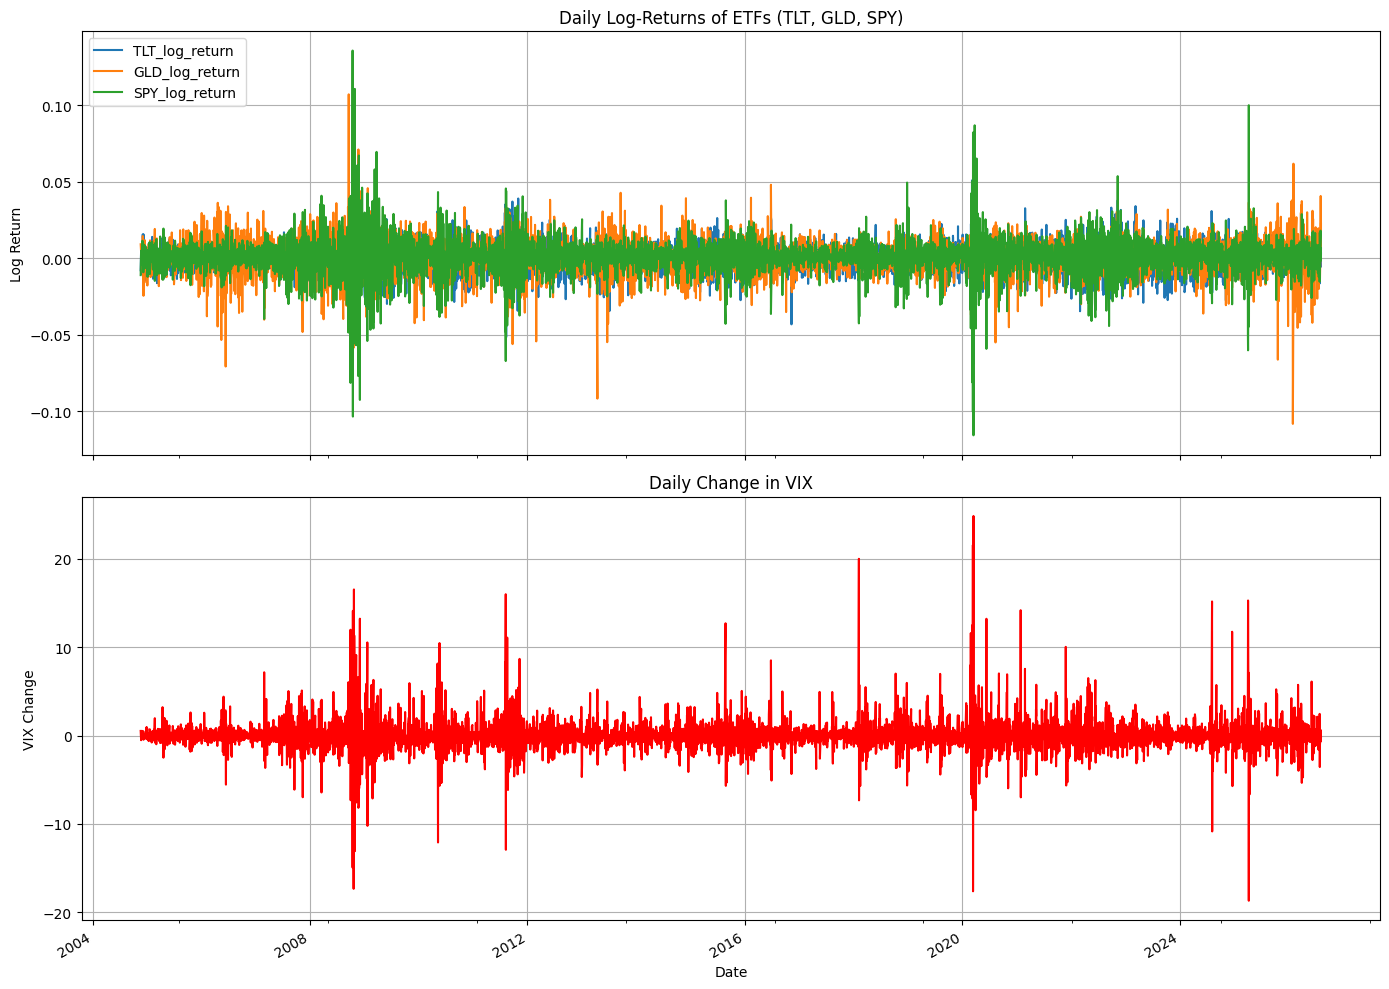

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot ETF returns over time
combined_data[['TLT_log_return', 'GLD_log_return', 'SPY_log_return']].plot(ax=axes[0])
axes[0].set_title('Daily Log-Returns of ETFs (TLT, GLD, SPY)')
axes[0].set_ylabel('Log Return')
axes[0].grid(True)

# Plot VIX change over time
combined_data['VIX_change'].plot(ax=axes[1], color='red')
axes[1].set_title('Daily Change in VIX')
axes[1].set_ylabel('VIX Change')
axes[1].set_xlabel('Date')
axes[1].grid(True)

plt.tight_layout()
plt.show()